# Loan Default Prediction — LendingClub

## Overview
Binary classification model to predict whether a borrower will fully repay or default on a loan, 
using historical data from LendingClub — a US peer-to-peer lending platform.

## Dataset
- ~390,000 loan records with 27 features
- Target variable: `loan_status` (Fully Paid / Charged Off)
- Source: https://www.kaggle.com/wordsforthewise/lending-club
## Approach
1. Exploratory Data Analysis (EDA)
2. Feature Engineering & Preprocessing
3. Neural Network modeling with Keras/TensorFlow
4. Model evaluation and threshold optimization for business-driven decision making



<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>LoanStatNew</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>loan_amnt</td>
      <td>The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.</td>
    </tr>
    <tr>
      <th>1</th>
      <td>term</td>
      <td>The number of payments on the loan. Values are in months and can be either 36 or 60.</td>
    </tr>
    <tr>
      <th>2</th>
      <td>int_rate</td>
      <td>Interest Rate on the loan</td>
    </tr>
    <tr>
      <th>3</th>
      <td>installment</td>
      <td>The monthly payment owed by the borrower if the loan originates.</td>
    </tr>
    <tr>
      <th>4</th>
      <td>grade</td>
      <td>LC assigned loan grade</td>
    </tr>
    <tr>
      <th>5</th>
      <td>sub_grade</td>
      <td>LC assigned loan subgrade</td>
    </tr>
    <tr>
      <th>6</th>
      <td>emp_title</td>
      <td>The job title supplied by the Borrower when applying for the loan.*</td>
    </tr>
    <tr>
      <th>7</th>
      <td>emp_length</td>
      <td>Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.</td>
    </tr>
    <tr>
      <th>8</th>
      <td>home_ownership</td>
      <td>The home ownership status provided by the borrower during registration or obtained from the credit report. Our values are: RENT, OWN, MORTGAGE, OTHER</td>
    </tr>
    <tr>
      <th>9</th>
      <td>annual_inc</td>
      <td>The self-reported annual income provided by the borrower during registration.</td>
    </tr>
    <tr>
      <th>10</th>
      <td>verification_status</td>
      <td>Indicates if income was verified by LC, not verified, or if the income source was verified</td>
    </tr>
    <tr>
      <th>11</th>
      <td>issue_d</td>
      <td>The month which the loan was funded</td>
    </tr>
    <tr>
      <th>12</th>
      <td>loan_status</td>
      <td>Current status of the loan</td>
    </tr>
    <tr>
      <th>13</th>
      <td>purpose</td>
      <td>A category provided by the borrower for the loan request.</td>
    </tr>
    <tr>
      <th>14</th>
      <td>title</td>
      <td>The loan title provided by the borrower</td>
    </tr>
    <tr>
      <th>15</th>
      <td>zip_code</td>
      <td>The first 3 numbers of the zip code provided by the borrower in the loan application.</td>
    </tr>
    <tr>
      <th>16</th>
      <td>addr_state</td>
      <td>The state provided by the borrower in the loan application</td>
    </tr>
    <tr>
      <th>17</th>
      <td>dti</td>
      <td>A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income.</td>
    </tr>
    <tr>
      <th>18</th>
      <td>earliest_cr_line</td>
      <td>The month the borrower's earliest reported credit line was opened</td>
    </tr>
    <tr>
      <th>19</th>
      <td>open_acc</td>
      <td>The number of open credit lines in the borrower's credit file.</td>
    </tr>
    <tr>
      <th>20</th>
      <td>pub_rec</td>
      <td>Number of derogatory public records</td>
    </tr>
    <tr>
      <th>21</th>
      <td>revol_bal</td>
      <td>Total credit revolving balance</td>
    </tr>
    <tr>
      <th>22</th>
      <td>revol_util</td>
      <td>Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.</td>
    </tr>
    <tr>
      <th>23</th>
      <td>total_acc</td>
      <td>The total number of credit lines currently in the borrower's credit file</td>
    </tr>
    <tr>
      <th>24</th>
      <td>initial_list_status</td>
      <td>The initial listing status of the loan. Possible values are – W, F</td>
    </tr>
    <tr>
      <th>25</th>
      <td>application_type</td>
      <td>Indicates whether the loan is an individual application or a joint application with two co-borrowers</td>
    </tr>
    <tr>
      <th>26</th>
      <td>mort_acc</td>
      <td>Number of mortgage accounts.</td>
    </tr>
    <tr>
      <th>27</th>
      <td>pub_rec_bankruptcies</td>
      <td>Number of public record bankruptcies</td>
    </tr>
  </tbody>
</table>


## Helper Function — Feature Description
LendingClub provides a data dictionary describing each column. 
The function below allows quick lookup of any feature's definition 
throughout the notebook, avoiding the need to consult the raw info file repeatedly.

In [1]:
import pandas as pd
data_info = pd.read_csv('DATA/lending_club_info.csv',index_col='LoanStatNew')
def feat_info(col_name):
    print(data_info.loc[col_name]['Description'])
feat_info('mort_acc')

Number of mortgage accounts.


## Imports & Data Loading

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('DATA/lending_club_loan_two.csv')
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274 non-null  str    
 15  dti        

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


## Exploratory Data Analysis (EDA)

Before modeling, we explore the dataset to understand distributions, identify patterns, 
and surface insights that will directly inform preprocessing and modeling decisions.

### Target Variable Distribution
Analyzing the balance between Fully Paid and Charged Off loans.
A significant imbalance here would require special handling during model training.

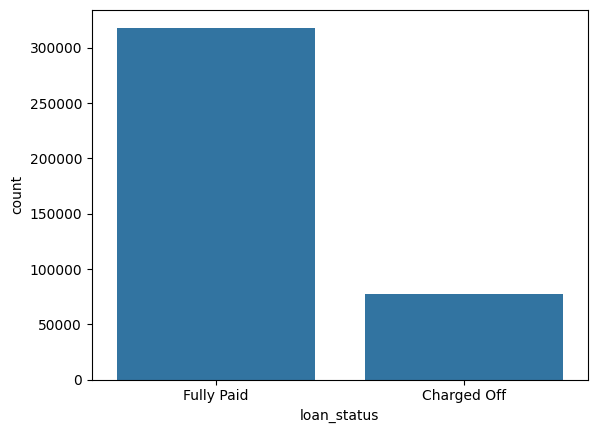

In [3]:
sns.countplot(x=df['loan_status'])
plt.savefig('images/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Loan Amount Distribution
Understanding the range and distribution of requested loan amounts 
across the dataset.

<Axes: xlabel='loan_amnt', ylabel='Count'>

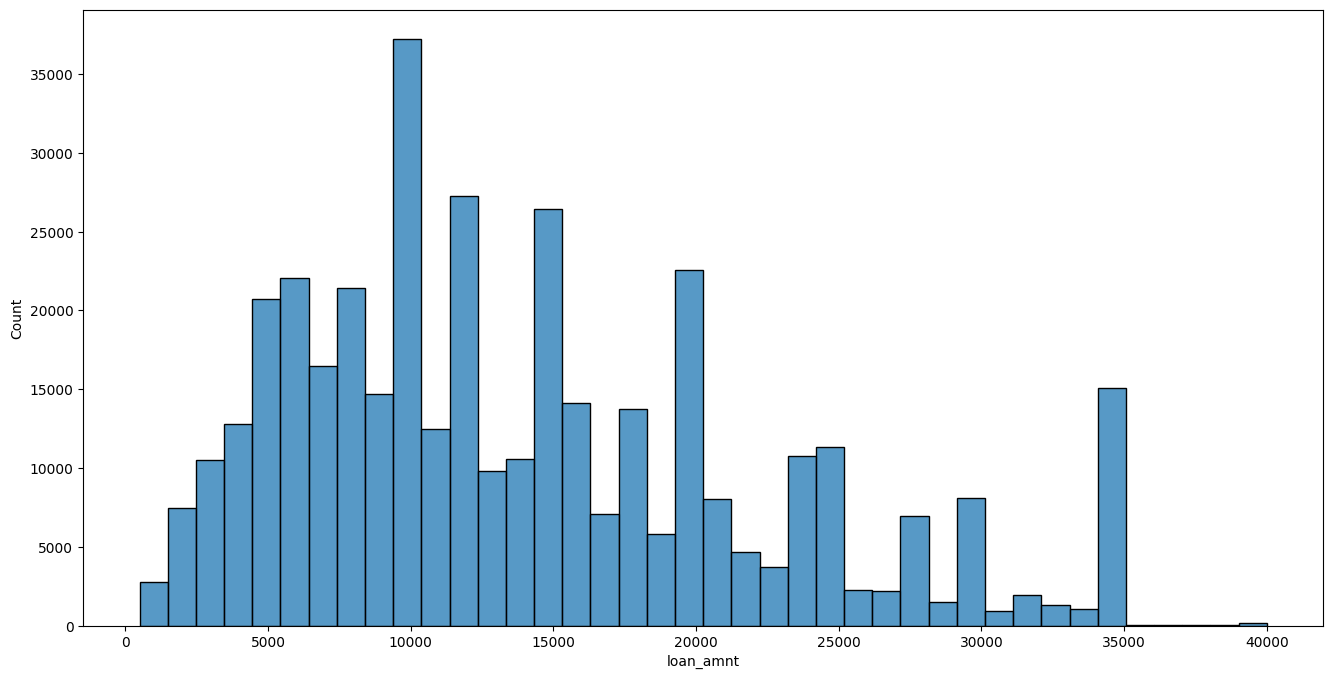

In [4]:
plt.figure(figsize=(16,8))
sns.histplot(x=df['loan_amnt'],bins=40)

<Axes: xlabel='loan_amnt', ylabel='Count'>

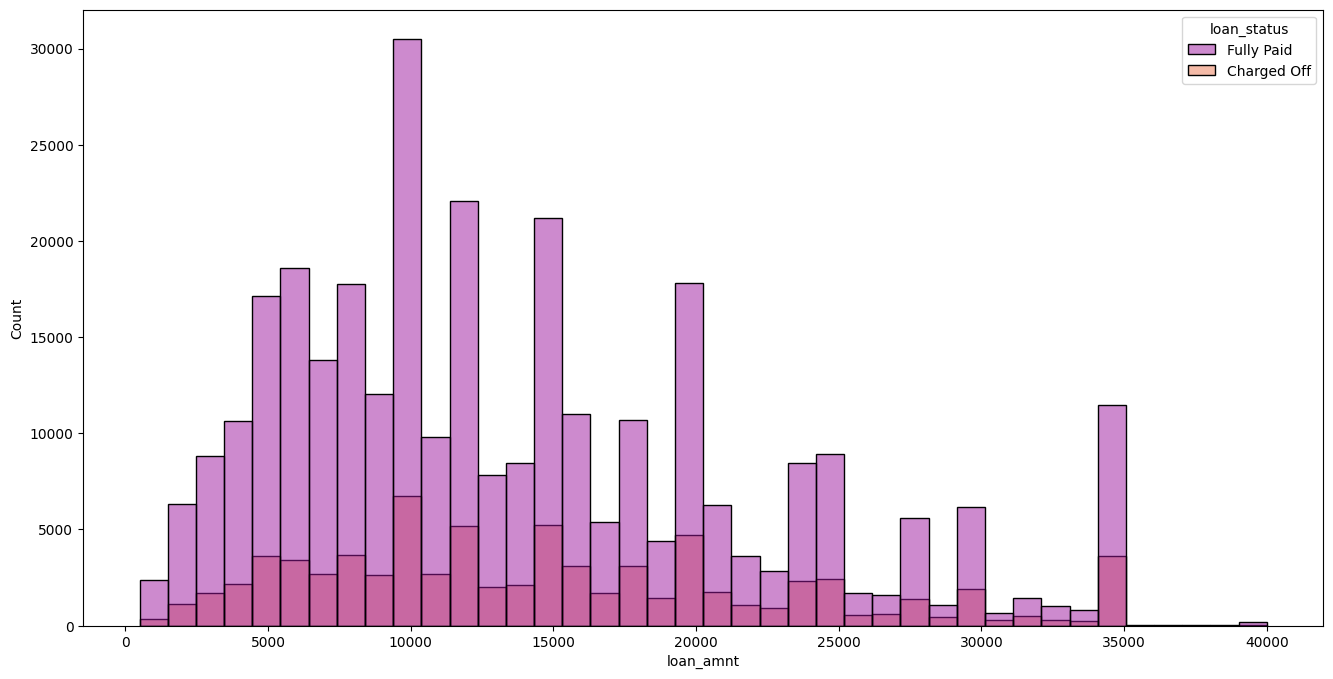

In [5]:
plt.figure(figsize=(16,8))
sns.histplot(data=df,x='loan_amnt',bins=40,hue='loan_status',palette='plasma')

### Interest Rate Distribution
Analyzing the overall distribution of interest rates across the dataset 
to understand the risk profile of loans offered on the platform.

<Axes: xlabel='int_rate', ylabel='Count'>

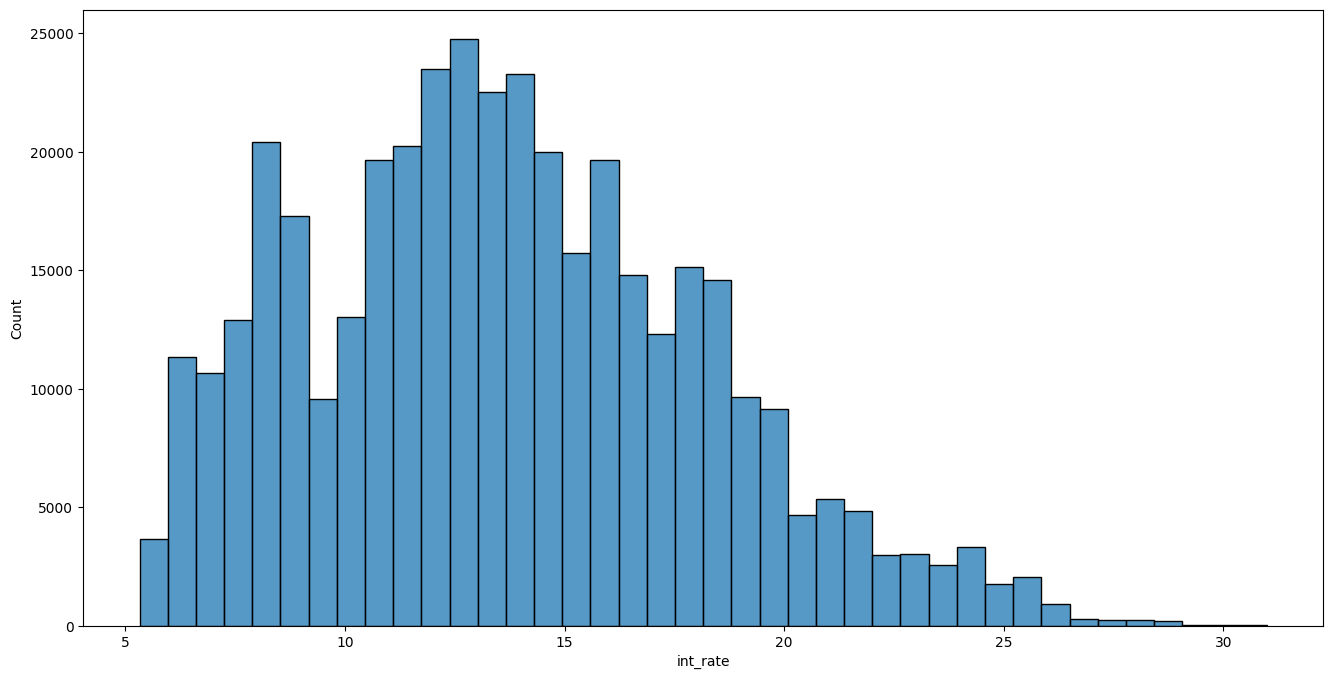

In [6]:
plt.figure(figsize=(16,8))
sns.histplot(x=df['int_rate'],bins=40)

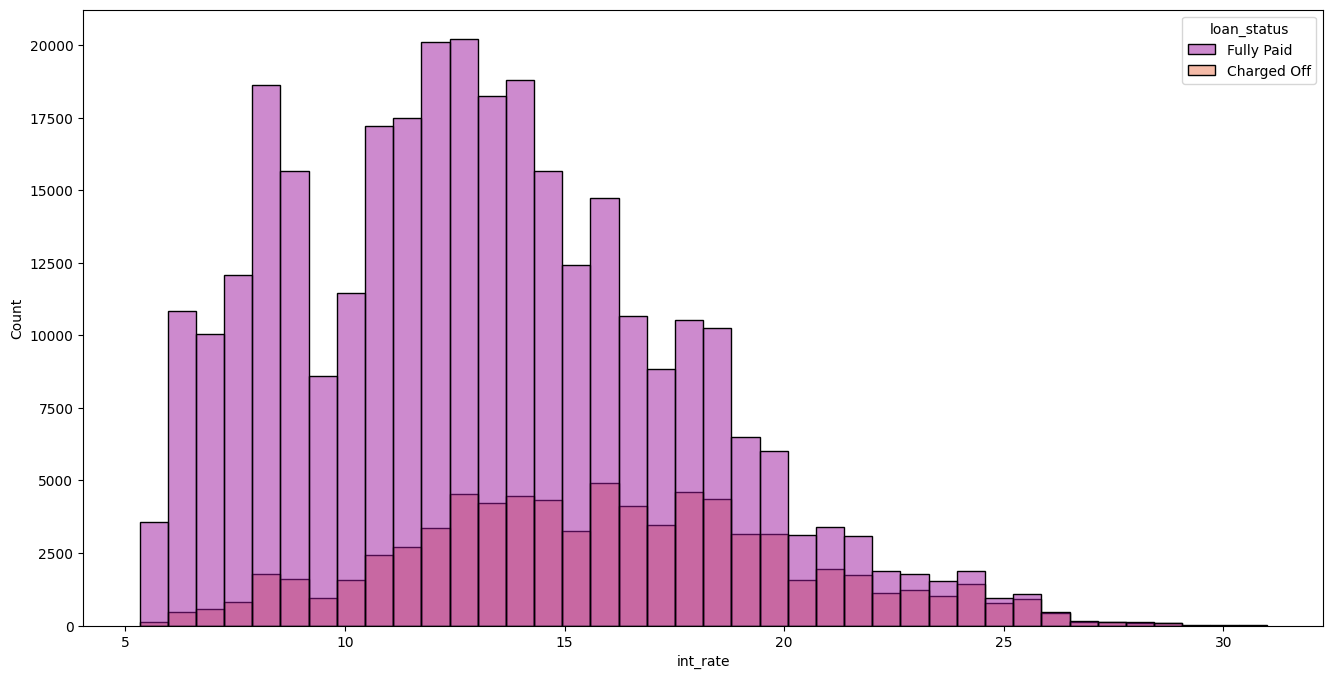

In [7]:
plt.figure(figsize=(16,8))
sns.histplot(data=df,x='int_rate',bins=40,hue='loan_status',palette='plasma')
plt.savefig('images/interest_rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Correlation
Identifying highly correlated features to avoid redundant information 
being passed to the model.

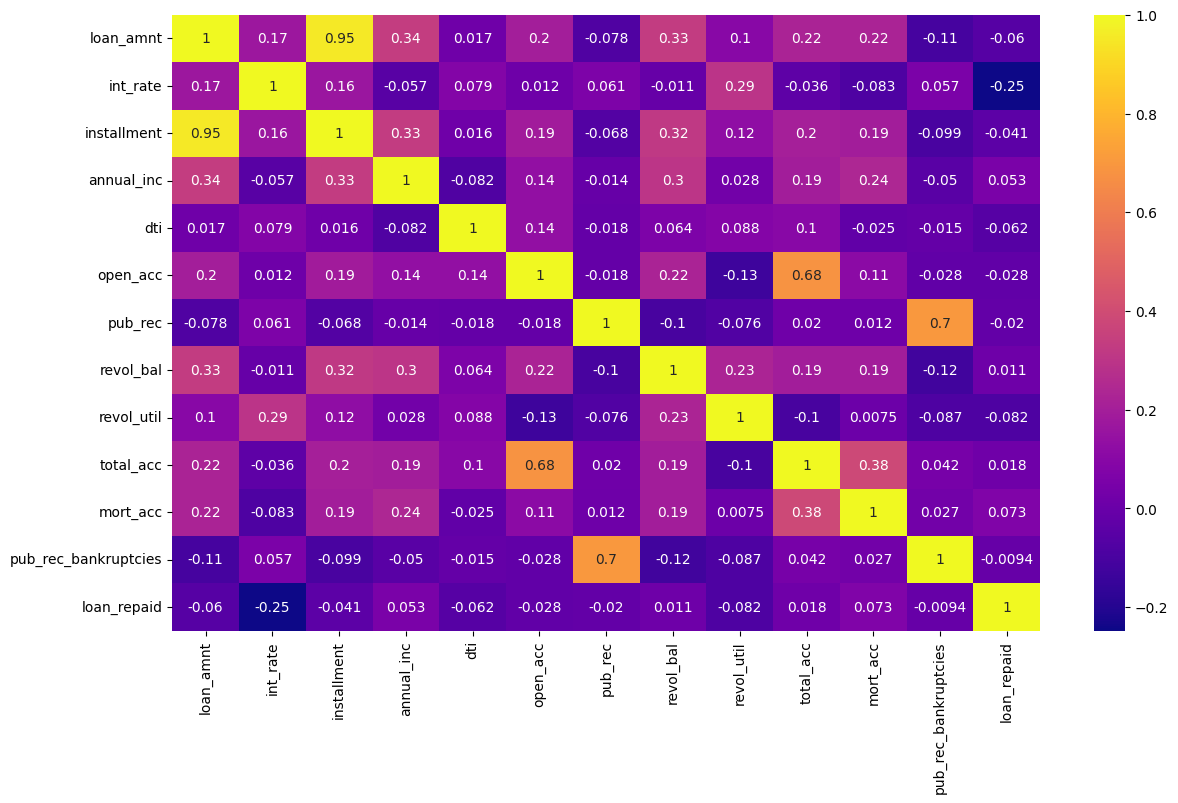

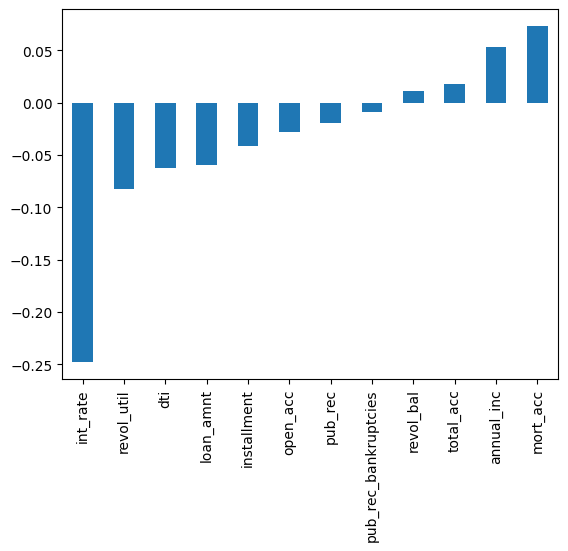



The monthly payment owed by the borrower if the loan originates.


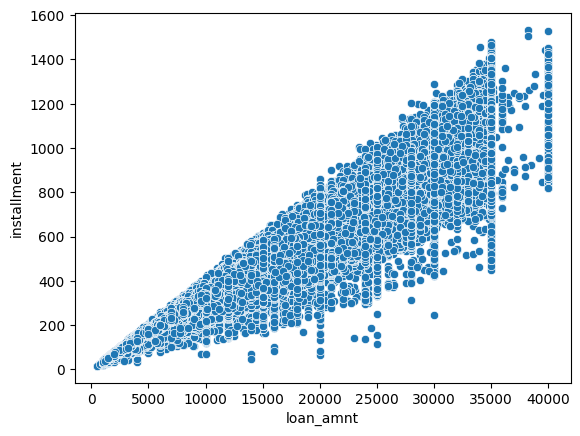

In [8]:
df['loan_repaid'] = df["loan_status"].apply(lambda x: 1 if x == 'Fully Paid' else 0) # Creating a new numeric column based off on "loan_status" 

plt.figure(figsize=(14,8))
sns.heatmap(df.select_dtypes(include="number").corr(),annot=True,cmap='plasma')
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n')

df.corr(numeric_only=True)['loan_repaid'].drop('loan_repaid').sort_values().plot(kind='bar')
plt.show()

print('\n')

feat_info('installment')
sns.scatterplot(data=df,y='installment', x='loan_amnt')
plt.show()

# Since "installment is basically duplicate information it can be dropped"
df = df.drop('installment', axis=1)

### Default Rate by Grade and Subgrade
LendingClub assigns risk grades (A to G) to each loan. 
Analyzing whether these grades effectively capture default risk.

['A' 'B' 'C' 'D' 'E' 'F' 'G']


['A1' 'A2' 'A3' 'A4' 'A5' 'B1' 'B2' 'B3' 'B4' 'B5' 'C1' 'C2' 'C3' 'C4'
 'C5' 'D1' 'D2' 'D3' 'D4' 'D5' 'E1' 'E2' 'E3' 'E4' 'E5' 'F1' 'F2' 'F3'
 'F4' 'F5' 'G1' 'G2' 'G3' 'G4' 'G5']


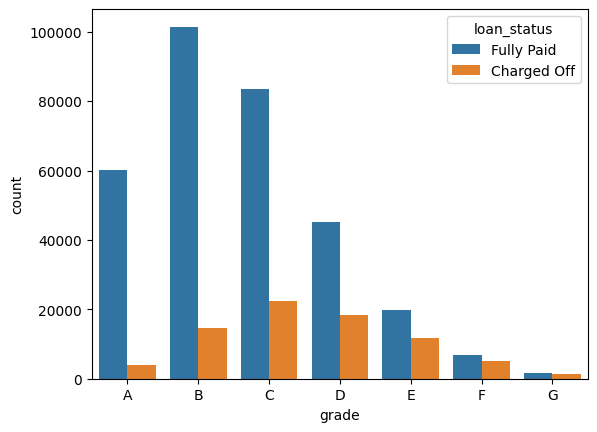

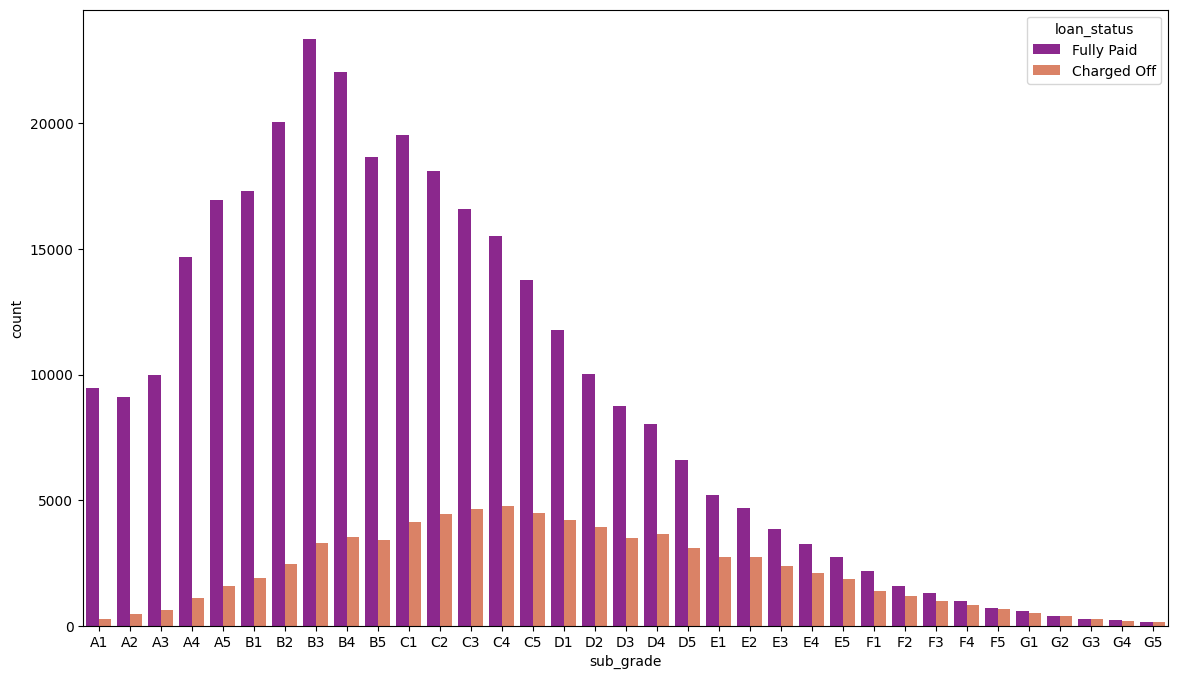

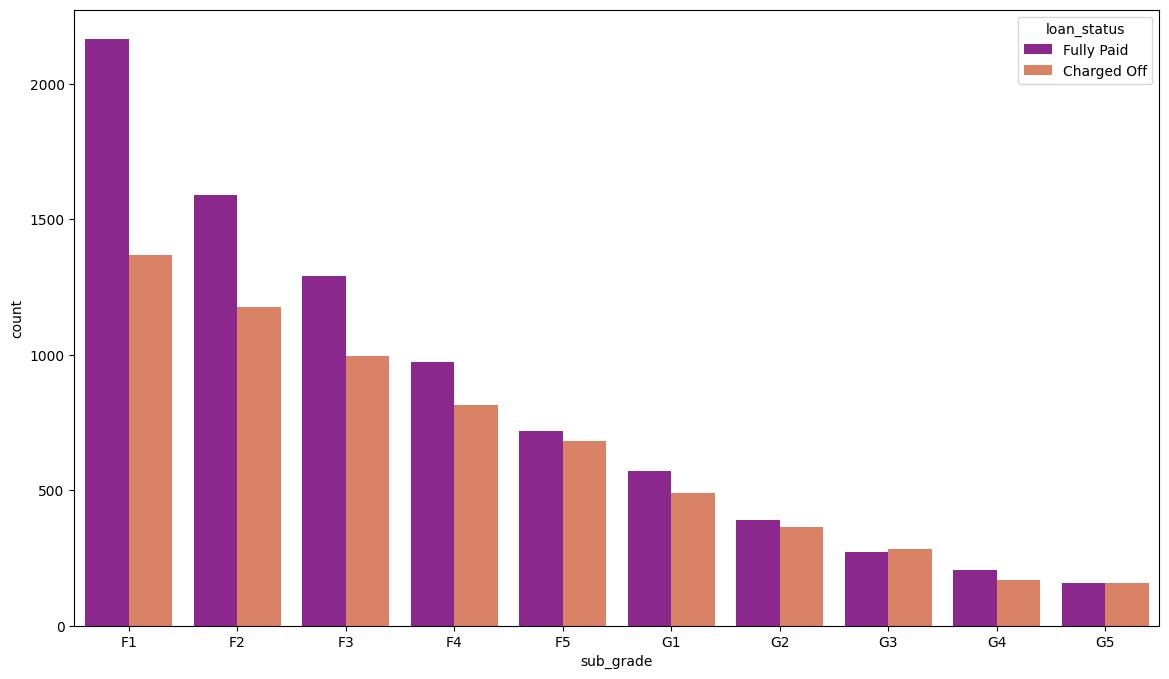

In [9]:
print(np.sort(df['grade'].unique()))
print('\n')
print(np.sort(df['sub_grade'].unique()))

order = np.sort(df['grade'].unique())
sns.countplot(data=df,x='grade',hue='loan_status', order=order)
plt.show()

order = sorted(df["sub_grade"].dropna().unique(), key=lambda s: (s[0], int(s[1:])))
plt.figure(figsize=(14,8))
sns.countplot(data=df,x='sub_grade',hue='loan_status',order=order,palette='plasma')
plt.savefig('images/default_rate_subgrade.png', dpi=150, bbox_inches='tight')
plt.show()

# It looks like F and G subgrades don't get paid back that often. Lets take a deeper dive into them.
plt.figure(figsize=(14,8))
dft = df.loc[df["sub_grade"] >= "F1"].copy()
order = sorted(dft["sub_grade"].dropna().unique(), key=lambda s: (s[0], int(s[1:])))
sns.countplot(data=dft,x='sub_grade',hue='loan_status',order=order,palette='plasma')
plt.show()

## Feature Engineering & Preprocessing

Based on the insights from the EDA, we now prepare the dataset for modeling.
This involves creating the target variable, removing features that are redundant 
or lack predictive power, handling missing data, encoding categorical variables, creating test train splits and normalizing the data.
All transformation decisions are grounded in the exploratory analysis performed above.

### Missing Data
Identifying and handling null values across the dataset. 
Each feature is treated differently based on the volume of missing data 
and its relationship with other variables.

In [10]:
print(df.isna().sum())
print('='*60)
(df.isna().sum()/len(df)) * 100 # Missing values in percentage

loan_amnt                   0
term                        0
int_rate                    0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
loan_repaid                 0
dtype: int64


loan_amnt               0.000000
term                    0.000000
int_rate                0.000000
grade                   0.000000
sub_grade               0.000000
emp_title               5.789208
emp_length              4.621115
home_ownership          0.000000
annual_inc              0.000000
verification_status     0.000000
issue_d                 0.000000
loan_status             0.000000
purpose                 0.000000
title                   0.443401
dti                     0.000000
earliest_cr_line        0.000000
open_acc                0.000000
pub_rec                 0.000000
revol_bal               0.000000
revol_util              0.069692
total_acc               0.000000
initial_list_status     0.000000
application_type        0.000000
mort_acc                9.543469
pub_rec_bankruptcies    0.135091
address                 0.000000
loan_repaid             0.000000
dtype: float64

### Removing High-Cardinality Feature — `emp_title`

`emp_title` contains the borrower's job title as free text, resulting in 
an extremely high number of unique values. Converting it to dummy variables 
would create an unmanageable number of columns with little predictive signal. 
The feature is dropped.

In [11]:
print(df['emp_title'].value_counts())

df = df.drop('emp_title',axis=1)

emp_title
Teacher                      4389
Manager                      4250
Registered Nurse             1856
RN                           1846
Supervisor                   1830
                             ... 
Retirement Counselor            1
Data Center Specialist II       1
Michael's Arts & Crafts         1
licensed bankere                1
Gracon Services, Inc            1
Name: count, Length: 173105, dtype: int64


### Removing Low-Signal Feature — `emp_length`

As observed, default rates remain consistent across all employment 
length categories, indicating that this feature adds little predictive value. 
It is removed to reduce noise in the model.

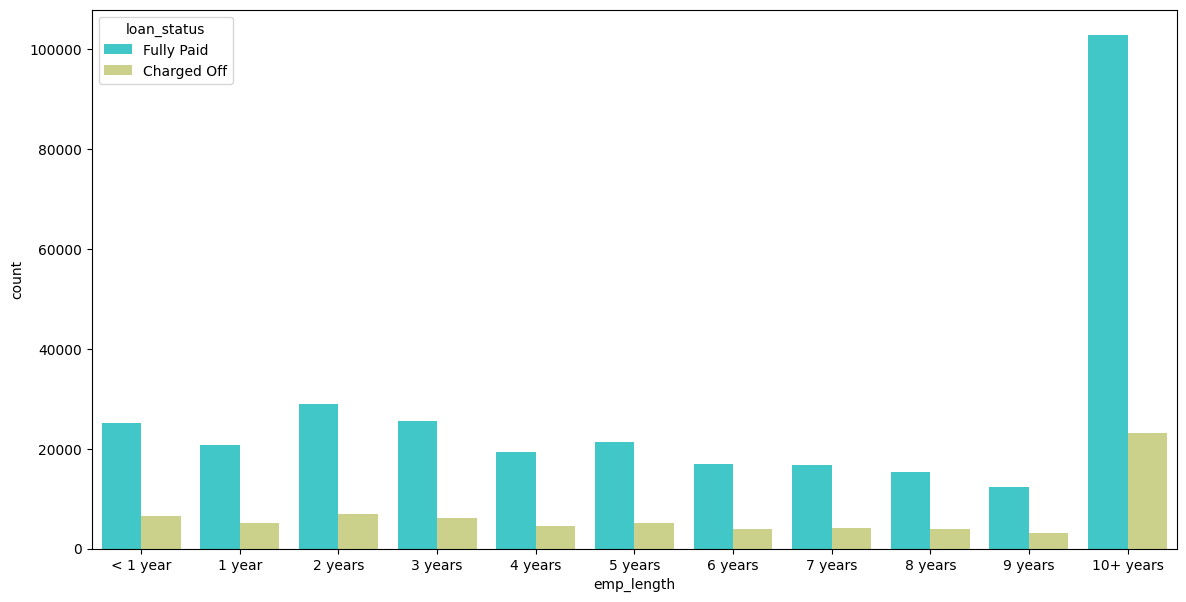

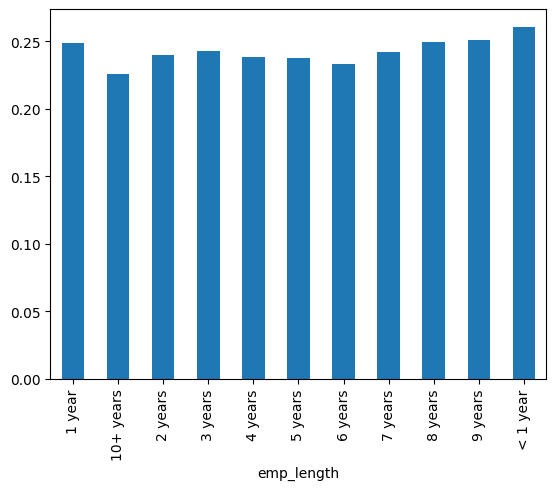

In [12]:
plt.figure(figsize=(14,7))
order=['< 1 year','1 year','2 years','3 years','4 years','5 years','6 years','7 years','8 years','9 years','10+ years']
sns.countplot(data=df, x = df['emp_length'].sort_values(),palette='rainbow', hue=df['loan_status'] ,order=order)
plt.show()

print('\n')

emp_co = df[df['loan_status'] == 'Charged Off'].groupby('emp_length').count()['loan_status']
emp_fp = df[df['loan_status'] == 'Fully Paid'].groupby('emp_length').count()['loan_status']
emp_len = emp_co/emp_fp
emp_len.plot(kind="bar")

df = df.drop('emp_length',axis=1)

### Removing Redundant Features — `title` & `purpose`

`title` is a borrower-written loan description that largely duplicates the information 
already captured by `purpose`, a standardized categorical variable. 
To avoid redundancy, `title` is dropped and `purpose` is retained.

In [13]:
feat_info('title')

print('\n')

df['title'].head(10)

The loan title provided by the borrower




0                   Vacation
1         Debt consolidation
2    Credit card refinancing
3    Credit card refinancing
4      Credit Card Refinance
5         Debt consolidation
6           Home improvement
7       No More Credit Cards
8         Debt consolidation
9         Debt Consolidation
Name: title, dtype: str

In [14]:
# It is basically the same information in the purpose column
feat_info('purpose')

print('\n')

df['purpose'].head(10)

A category provided by the borrower for the loan request. 




0              vacation
1    debt_consolidation
2           credit_card
3           credit_card
4           credit_card
5    debt_consolidation
6      home_improvement
7           credit_card
8    debt_consolidation
9    debt_consolidation
Name: purpose, dtype: str

In [15]:
df = df.drop('title', axis=1)

### Handling Missing Values — `mort_acc`

`mort_acc` (number of mortgage accounts) has ~10% missing values — too significant to drop.

Rather than imputing with the global mean, we apply **group-mean imputation**: 
we identify `total_acc` as the feature most correlated with `mort_acc`, 
compute the mean of `mort_acc` for each value of `total_acc`, 
and use these group-level means to fill the missing entries.

This preserves variation across borrower profiles and produces more 
representative estimates than a single global average.

In [16]:
feat_info('mort_acc')

print('\n')

print(df.corr(numeric_only=True)['mort_acc'].sort_values())

total_acc_avg = df.groupby('total_acc')['mort_acc'].mean()

def fill_mort_acc(row):
    if pd.isna(row['mort_acc']):
        return total_acc_avg[row['total_acc']]
    else:
        return row['mort_acc']


df['mort_acc'] = df.apply(fill_mort_acc, axis=1)

Number of mortgage accounts.


int_rate               -0.082583
dti                    -0.025439
revol_util              0.007514
pub_rec                 0.011552
pub_rec_bankruptcies    0.027239
loan_repaid             0.073111
open_acc                0.109205
revol_bal               0.194925
loan_amnt               0.222315
annual_inc              0.236320
total_acc               0.381072
mort_acc                1.000000
Name: mort_acc, dtype: float64


### Handling Remaining Missing Values — `revol_util` & `pub_rec_bankruptcies`

Both features have a negligible proportion of missing values. 
Given the minimal data loss, rows with null entries are dropped directly via `dropna()`.

In [17]:
df = df.dropna()
df.isnull().sum()

loan_amnt               0
term                    0
int_rate                0
grade                   0
sub_grade               0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0
loan_repaid             0
dtype: int64

### Categorical Variables — Encoding with Dummy Variables

Categorical features need to be converted to numerical format before being passed to the model.
We apply `pd.get_dummies()` to encode each categorical column, dropping the first category 
to avoid multicollinearity.

In [18]:
df.select_dtypes(exclude=['number'])

,term,grade,sub_grade,home_ownership,verification_status,issue_d,loan_status,purpose,earliest_cr_line,initial_list_status,application_type,address
0,36 months,B,B4,RENT,Not Verified,Jan-2015,Fully Paid,vacation,Jun-1990,w,INDIVIDUAL,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,36 months,B,B5,MORTGAGE,Not Verified,Jan-2015,Fully Paid,debt_consolidation,Jul-2004,f,INDIVIDUAL,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,36 months,B,B3,RENT,Source Verified,Jan-2015,Fully Paid,credit_card,Aug-2007,f,INDIVIDUAL,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,36 months,A,A2,RENT,Not Verified,Nov-2014,Fully Paid,credit_card,Sep-2006,f,INDIVIDUAL,"823 Reid Ford\nDelacruzside, MA 00813"
4,60 months,C,C5,MORTGAGE,Verified,Apr-2013,Charged Off,credit_card,Mar-1999,f,INDIVIDUAL,"679 Luna Roads\nGreggshire, VA 11650"
...,...,...,...,...,...,...,...,...,...,...,...,...
396025,60 months,B,B4,RENT,Source Verified,Oct-2015,Fully Paid,debt_consolidation,Nov-2004,w,INDIVIDUAL,"12951 Williams Crossing\nJohnnyville, DC 30723"
396026,36 months,C,C1,MORTGAGE,Source Verified,Feb-2015,Fully Paid,debt_consolidation,Feb-2006,f,INDIVIDUAL,"0114 Fowler Field Suite 028\nRachelborough, LA..."
396027,36 months,B,B1,RENT,Verified,Oct-2013,Fully Paid,debt_consolidation,Mar-1997,f,INDIVIDUAL,"953 Matthew Points Suite 414\nReedfort, NY 70466"
396028,60 months,C,C2,MORTGAGE,Verified,Aug-2012,Fully Paid,debt_consolidation,Nov-1990,f,INDIVIDUAL,"7843 Blake Freeway Apt. 229\nNew Michael, FL 2..."


In [19]:
df.select_dtypes(exclude=['number']).columns.tolist()

['term',
 'grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'purpose',
 'earliest_cr_line',
 'initial_list_status',
 'application_type',
 'address']

### `term` Column
The `term` column represents the loan duration as a string ("36 months" / "60 months"). 
We extract the numeric value directly, avoiding the need for dummy encoding.

In [20]:
df['term'] = df['term'].apply(lambda x: 36 if x == '36 months' else 60)

### `grade` & `sub_grade` Columns
`grade` is redundant since `sub_grade` already contains the same information at a finer level 
(e.g., A1–A5 implies grade A). We drop `grade` and apply dummy encoding to `sub_grade` only.

In [21]:
df = df.drop('grade', axis=1)
dummies = pd.get_dummies(df['sub_grade'], drop_first=True)
df = pd.concat([df.drop('sub_grade', axis=1), dummies],axis=1)

### `home_ownership` Column
Rare categories (`NONE`, `ANY`, `OTHER`) are dropped before encoding, 
as they represent a negligible portion of the data and would add noise. 
Dummy encoding is then applied to the remaining categories.

In [22]:
print(df['home_ownership'].value_counts())

df = df.drop(df[df['home_ownership'] == 'ANY'].index)
df = df.drop(df[df['home_ownership'] == 'OTHER'].index)
df = df.drop(df[df['home_ownership'] == 'NONE'].index)

d = pd.get_dummies(df['home_ownership'], drop_first=True)

df = pd.concat([df.drop('home_ownership', axis=1), d],axis=1)

home_ownership
MORTGAGE    198022
RENT        159395
OWN          37660
OTHER          110
NONE            29
ANY              3
Name: count, dtype: int64


### `address` Column — ZIP Code Extraction
The full address string is not directly useful for modeling. 
We extract the ZIP code using regex and apply dummy encoding to it, 
capturing potential geographic patterns in default rates.

In [23]:
df['zip_code'] = df['address'].str[-5:]
d = pd.get_dummies(df['zip_code'])
df = pd.concat([df.drop('zip_code', axis=1), d],axis=1)
df = df.drop('address', axis=1)

### Dropping `issue_d` — Data Leakage
`issue_d` represents the month the loan was issued. This information would not be 
available at prediction time, as the model is meant to assess default risk 
before the loan is issued. Keeping it would constitute data leakage and 
produce artificially inflated performance metrics.

In [24]:
df = df.drop('issue_d', axis =1)

### `earliest_cr_line` — Year Extraction
`earliest_cr_line` represents the date of the borrower's earliest credit line as a timestamp. 
We extract the year only, creating a new feature `earliest_cr_year` that captures 
credit history length in a simpler, model-friendly format.

In [25]:
df['earliest_cr_year'] = df['earliest_cr_line'].str[-4:]
df['earliest_cr_year'] = df['earliest_cr_year'].apply(lambda x: int(x))
df =  df.drop('earliest_cr_line',axis=1)

### Remaining Categorical Columns
`verification_status`, `application_type`, `initial_list_status`, and `purpose` are 
standard categorical features with a manageable number of unique values. 
Dummy encoding is applied directly to each.

In [26]:
columns = ['verification_status', 'application_type','initial_list_status','purpose']
for c in columns:
    dummies = pd.get_dummies(df[c], drop_first=True)
    df = pd.concat([df.drop(c, axis=1), dummies],axis=1)

### Target Variable & Train/Test Split
Earlier in preprocessing, we created `loan_repaid` as a binary target variable 
derived from `loan_status`. 
`loan_status` is now dropped to prevent leakage, and the dataset is split 
into training and test sets (80/20).

In [27]:
from sklearn.model_selection import train_test_split

df = df.drop('loan_status', axis=1)

X = df.drop('loan_repaid',axis=1)
y = df['loan_repaid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

### Feature Normalization
We apply `MinMaxScaler` to normalize all features to a [0, 1] range, 
which is important for neural network training. 
The scaler is fit exclusively on the training set and then applied to both 
train and test sets, preventing data leakage from the test distribution.

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model — Neural Network (Keras/TensorFlow)

We build a sequential neural network to classify loans as fully paid or charged off.
The architecture, regularization strategy, and training configuration are described below.

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

### Model Architecture
A sequential neural network with three Dense layers of decreasing size (78 → 39 → 19), 
designed to progressively compress the feature space — the first layer matches the number 
of input features (78 columns after encoding), with each subsequent layer halving the size.

ReLU activation is used in all hidden layers for its computational efficiency and 
ability to mitigate the vanishing gradient problem in deeper networks.

Dropout layers (rate=0.2) are added after the second and third Dense layers to reduce 
overfitting by randomly deactivating neurons during training.

The output layer uses a single neuron with sigmoid activation, producing a probability 
score between 0 and 1 for binary classification.

To address the class imbalance identified in the EDA, `class_weight` is applied during 
training, penalizing misclassification of the minority class (Charged Off) proportionally.

In [30]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

model = Sequential()

model.add(Dense(78))
model.add(Dense(39, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(19, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

### Model Training
The model is trained for up to 150 epochs with a batch size of 1024. 
Early stopping monitors `val_loss` with a patience of 10 epochs, 
halting training when performance stops improving and restoring 
the weights from the best epoch — preventing overfitting and 
removing the need to manually tune the number of epochs.

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

model.fit(x=X_train,
          y=y_train,
          epochs=150,
          validation_data=(X_test, y_test),
          verbose=1,
          class_weight=class_weights_dict,
          batch_size=1024,
          callbacks=[early_stop]
          )

Epoch 1/150
309/309 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7757 - loss: 0.4200 - val_accuracy: 0.7751 - val_loss: 0.3711
Epoch 2/150
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7801 - loss: 0.3670 - val_accuracy: 0.8013 - val_loss: 0.3426
Epoch 3/150
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7837 - loss: 0.3646 - val_accuracy: 0.7914 - val_loss: 0.3516
Epoch 4/150
309/309 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7860 - loss: 0.3631 - val_accuracy: 0.7757 - val_loss: 0.3724
Epoch 5/150
309/309 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7853 - loss: 0.3630 - val_accuracy: 0.7836 - val_loss: 0.3598
Epoch 6/150
309/309 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7872 - loss: 0.3625 - val_accuracy: 0.7948 - val_loss: 0.3618
Epoch 7/150
309/309 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.7891 - loss: 0.3620 - val_accuracy: 0.7731 - val_loss: 0.3819
Epoch 8/150
309/309 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7896 - loss: 0.3611 - va

## Model Evaluation

We evaluate the model's performance on the test set using loss curves, 
classification metrics, and a confusion matrix. 
Following the standard evaluation, we perform a threshold analysis 
to determine the optimal decision boundary based on business criteria.

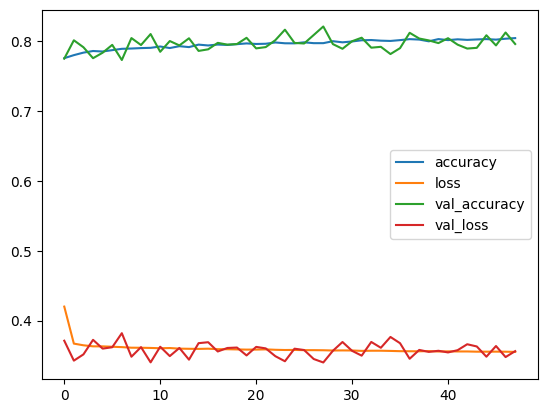

In [32]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()
plt.savefig('images/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Classification Report & Confusion Matrix
We generate predictions using the default decision threshold of 0.5 
and evaluate the model with a classification report and confusion matrix.
Note that threshold selection is explored in detail in the next section.

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
predictions = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, predictions))
print('\n')
print(confusion_matrix(y_test, predictions))

2470/2470 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step  
              precision    recall  f1-score   support

           0       0.53      0.76      0.63     15556
           1       0.93      0.84      0.88     63460

    accuracy                           0.82     79016
   macro avg       0.73      0.80      0.75     79016
weighted avg       0.86      0.82      0.83     79016



[[11834  3722]
 [10412 53048]]


### Results at Default Threshold (0.5)
The model achieves 82% overall accuracy. However, accuracy alone is misleading 
given the class imbalance — the more relevant metrics are precision and recall per class.

For the **Charged Off** class (0): recall of 0.76 means the model correctly identifies 
76% of actual defaults, but precision of 0.54 indicates a high false positive rate — 
many fully paid loans are being flagged as defaults.

For the **Fully Paid** class (1): both precision (0.93) and recall (0.84) are strong, 
reflecting the model's bias toward the majority class despite the `class_weight` correction.

These results motivate the threshold analysis in the next section — the default 0.5 
threshold may not be optimal depending on the business cost of each type of error.

### Threshold Analysis

The default threshold of 0.5 treats false positives and false negatives as equally costly. 
In a loan default prediction context, this assumption rarely holds — the business cost 
of approving a loan that defaults (false negative) is typically much higher than 
the cost of rejecting a loan that would have been repaid (false positive).

By adjusting the decision threshold, we can control the trade-off between precision 
and recall for each class. A higher threshold makes the model more conservative in 
predicting Fully Paid, flagging more loans as defaults — increasing recall for class 0 
at the cost of precision. A lower threshold does the opposite: fewer defaults are flagged, 
precision increases but many actual defaults go undetected.

We evaluate thresholds from 0.2 to 0.8 to identify the optimal decision boundary 
based on business criteria.

In [34]:
thresholds = [0.2, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.8]
probs = model.predict(X_test).flatten()

for t in thresholds:
    preds = (probs > t).astype(int)
    print(f'Prediction with "t"={t}')
    print(classification_report(y_test, preds))
    print(confusion_matrix(y_test, preds))
    print('\n\n')
    print('*' * 60)
    print('\n\n')

2470/2470 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Prediction with "t"=0.2
              precision    recall  f1-score   support

           0       0.99      0.44      0.61     15556
           1       0.88      1.00      0.93     63460

    accuracy                           0.89     79016
   macro avg       0.93      0.72      0.77     79016
weighted avg       0.90      0.89      0.87     79016

[[ 6813  8743]
 [   82 63378]]



************************************************************



Prediction with "t"=0.3
              precision    recall  f1-score   support

           0       0.86      0.51      0.64     15556
           1       0.89      0.98      0.93     63460

    accuracy                           0.89     79016
   macro avg       0.87      0.74      0.79     79016
weighted avg       0.88      0.89      0.88     79016

[[ 7927  7629]
 [ 1298 62162]]



************************************************************



Prediction with "t"=0.35
              precision    recall 

### Threshold Selection — Business Decision

The threshold analysis reveals a clear asymmetry in the cost of each type of error.
A defaulted loan of $14,000 represents a total loss of principal, while rejecting 
a good borrower at the same amount foregoes approximately $1,400 in interest revenue — 
a 10:1 cost ratio that strongly justifies a more aggressive threshold.

Based on this analysis, two thresholds are recommended depending on the company's strategy:

**Threshold = 0.6 (Conservative)**
Captures 88% of actual defaults while rejecting approximately 30% of good borrowers.
This balance preserves a meaningful customer base while significantly reducing default exposure.
Recommended for companies prioritizing sustainable growth and platform volume.

**Threshold = 0.7 (Aggressive)**
Captures 95% of actual defaults at the cost of rejecting ~42% of good borrowers.
While mathematically justifiable given the 10:1 cost ratio, this approach carries 
non-quantifiable risks — a shrinking customer base reduces platform liquidity and 
may affect investor confidence in a peer-to-peer lending model that depends on volume.
Recommended only if the company is deliberately pursuing margin optimization 
over growth, accepting a leaner, higher-margin operation as a strategic outcome.

The default threshold of 0.5 is not recommended in either scenario, 
as it underperforms on default capture without meaningfully protecting customer volume.

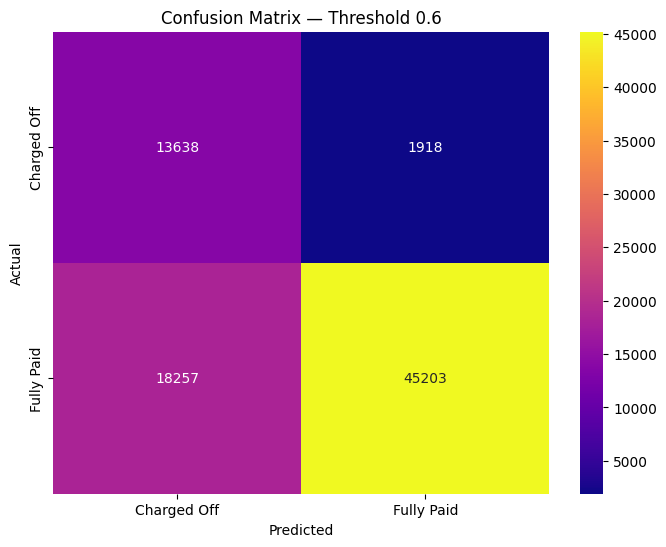

In [35]:
preds_06 = (probs > 0.6).astype(int)
cm_06 = confusion_matrix(y_test, preds_06)

plt.figure(figsize=(8,6))
sns.heatmap(cm_06, annot=True, fmt='d', cmap='plasma',
            xticklabels=['Charged Off', 'Fully Paid'],
            yticklabels=['Charged Off', 'Fully Paid'])
plt.title('Confusion Matrix — Threshold 0.6')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('images/confusion_matrix_06.png', dpi=150, bbox_inches='tight')
plt.show()

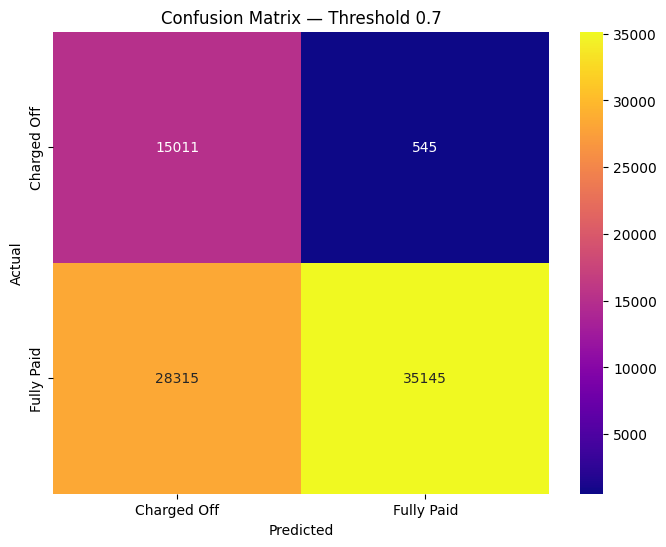

In [36]:
preds_07 = (probs > 0.7).astype(int)
cm_07 = confusion_matrix(y_test, preds_07)

plt.figure(figsize=(8,6))
sns.heatmap(cm_07, annot=True, fmt='d', cmap='plasma',
            xticklabels=['Charged Off', 'Fully Paid'],
            yticklabels=['Charged Off', 'Fully Paid'])
plt.title('Confusion Matrix — Threshold 0.7')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('images/confusion_matrix_07.png', dpi=150, bbox_inches='tight')
plt.show()